In [1]:
import os
import numpy as np

image_dataset_path = '/content/drive/MyDrive/Research_Work/Dr Indu Lathwal/Dataset/'
output_filename = 'preprocessed_image_dataset.npz'
full_output_path = os.path.join(image_dataset_path, output_filename)

loaded_data = np.load(full_output_path)
loaded_images = loaded_data['images']
loaded_labels = loaded_data['labels']

print(f"Verified: Loaded images shape: {loaded_images.shape}, Loaded labels shape: {loaded_labels.shape}")

Verified: Loaded images shape: (2767, 128, 128, 3), Loaded labels shape: (2767,)


In [2]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(loaded_labels)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(loaded_images, encoded_labels, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


# Flatten images for ANN (MLP)
X_train_ann = X_train.reshape(X_train.shape[0], -1)
X_test_ann = X_test.reshape(X_test.shape[0], -1)

print("ANN Input shape:", X_train_ann.shape)

X_train shape: (2213, 128, 128, 3)
X_test shape: (554, 128, 128, 3)
y_train shape: (2213,)
y_test shape: (554,)
ANN Input shape: (2213, 49152)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

# Determine number of classes
num_classes = len(np.unique(encoded_labels))

# Input size after flattening
input_dim = X_train_ann.shape[1]

# Define ANN model
model = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,624,840 (48.16 MB)

 Trainable params: 12,624,840 (48.16 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_ann, y_train,
                    epochs=20,
                    validation_data=(X_test_ann, y_test))

print("ANN Model training complete.")

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 28s 321ms/step - accuracy: 0.5890 - loss: 2.1097 - val_accuracy: 0.7671 - val_loss: 0.5790
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 280ms/step - accuracy: 0.8495 - loss: 0.4075 - val_accuracy: 0.8718 - val_loss: 0.4052
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 324ms/step - accuracy: 0.9244 - loss: 0.2232 - val_accuracy: 0.7978 - val_loss: 0.5282
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 449ms/step - accuracy: 0.9140 - loss: 0.2272 - val_accuracy: 0.8339 - val_loss: 0.4675
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 287ms/step - accuracy: 0.9057 - loss: 0.2922 - val_accuracy: 0.7870 - val_loss: 0.6017
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 293ms/step - accuracy: 0.8844 - loss: 0.3078 - val_accuracy: 0.8502 - val_loss: 0.4020
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 307ms/step - accuracy: 0.9514 - loss: 0.1338 - val_accuracy: 0.8466 - val_loss: 0.4918
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 261ms/step - accuracy: 0.9182 - loss: 0.2632 - val_accu

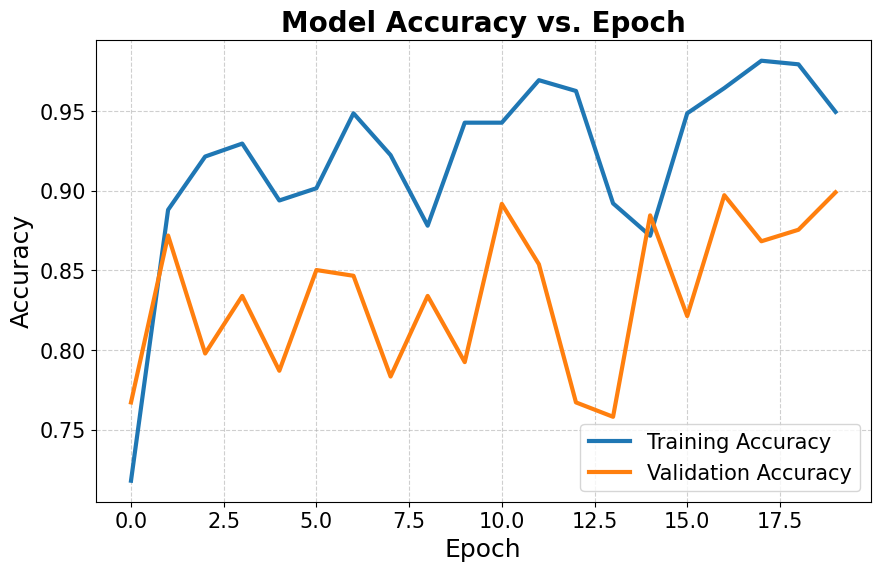

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], linewidth=3)
plt.plot(history.history['val_accuracy'], linewidth=3)

plt.title('Model Accuracy vs. Epoch', fontsize=20, fontweight='bold')
plt.xlabel('Epoch', fontsize=18)
plt.ylabel('Accuracy', fontsize=18)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)

#plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate
loss, accuracy = model.evaluate(X_test_ann, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Predictions
y_pred_probabilities = model.predict(X_test_ann)
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8989
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

Classification Report:
                  precision    recall  f1-score   support

   Hariana Front       0.89      0.94      0.91       180
    Hariana Left       0.91      0.71      0.80        55
Red_Sindhi Front       1.00      0.81      0.90        54
 Red_Sindhi Left       0.85      1.00      0.92        29
   Sahiwal Front       0.91      1.00      0.95        41
    Sahiwal Left       0.95      1.00      0.97        36
 Tharparkar Left       0.95      0.76      0.85        54
Tharparker Front       0.85      0.93      0.89       105

        accuracy                           0.90       554
       macro avg       0.91      0.90      0.90       554
    weighted avg       0.90      0.90      0.90       554


Confusion Matrix:
[[170   4   0   0   1   1   1   3]
 [ 14  39   0   0   0   1   0   1]
 [  2   0  44   5   3   0   0   0]
 [  0   0   0  29   0   0   0   0]
 [  0   0   0   0  41   0   0   0]
 [  0   0   0   0   0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


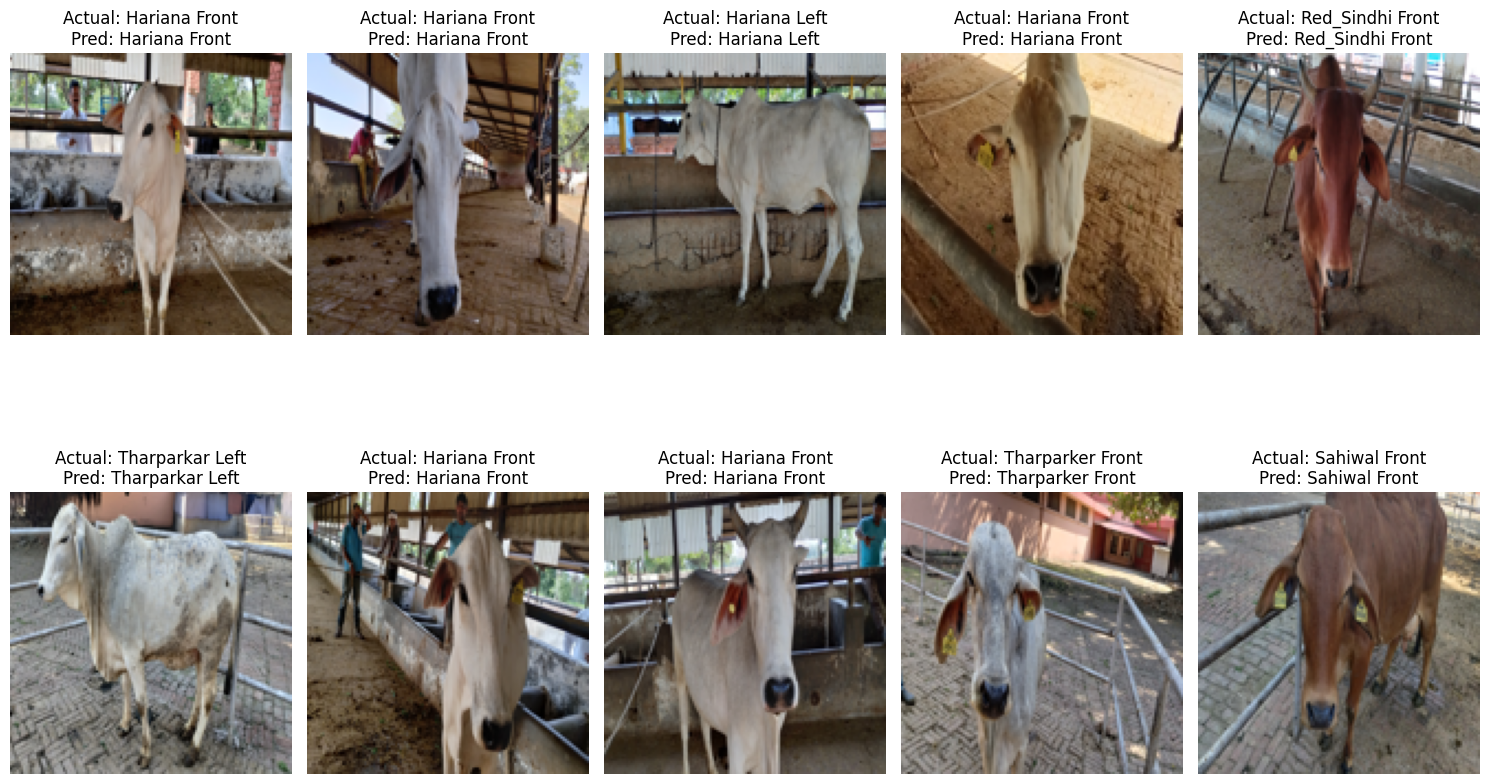

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Randomly select 10 indices from the test dataset
num_samples_to_show = 10
random_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

# Get the selected images and their true labels
sampled_images = X_test[random_indices]
sampled_true_labels = y_test[random_indices]

# Flatten the sampled images for ANN prediction
sampled_images_ann = sampled_images.reshape(sampled_images.shape[0], -1)

# Make predictions for the sampled images using the ANN model
sampled_predictions_probabilities = model.predict(sampled_images_ann)
sampled_predicted_labels = np.argmax(sampled_predictions_probabilities, axis=1)

# Inverse transform numerical labels back to original class names
sampled_true_class_names = label_encoder.inverse_transform(sampled_true_labels)
sampled_predicted_class_names = label_encoder.inverse_transform(sampled_predicted_labels)

# Plot the images with their actual and predicted labels
plt.figure(figsize=(15, 10))
for i in range(num_samples_to_show):
    plt.subplot(2, 5, i + 1) # Arrange plots in 2 rows, 5 columns
    plt.imshow(sampled_images[i])# Display image
    plt.title(f"Actual: {sampled_true_class_names[i]}\nPred: {sampled_predicted_class_names[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()